In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cinética de Procesos (Sesión 03)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 5. Reactores Semi-batch

## 5.1 Definiciones

### 5.1.1 Consideraciones generales

En principio, un reactor semi-batch funciona de forma similar a un reactor batch. 

La diferencia radica en que en un reactor semi-batch, se permite la adición de reactivos y/o remoción de productos mientras se opera el reactor.

<center>

<img src="figures/images/Fed_batch_reactor_FSTR.svg" style="width:200px" title="Batch Reactor">
<img src="figures/images/Continuous_bach_reactor_CSTR.svg" style="width:250px" title="Continuous Stirred Tank Reactor">

***Figura 01. Representación de un reactor Semi-batch.*** 

Tomado de: [YassineMrabet](https://commons.wikimedia.org/wiki/Category:Batch_reactors#/media/File:Fed_batch_reactor_FSTR.svg) 

</center>

**Utilización típica:**
- Operaciones en escala industrial.
- Reacciones en fase líquida.

**Ventajas:**
- Mezclado eficiente.
- Temperatura y composición uniformes.

**Desventajas:**
- Costo elevado por lote.
- Variabilidad de productos de lote a lote.

### 5.1.2 Ecuación de diseño

Un reactor semi-batch puede tener tanto entradas como salidas, por lo que la ecuación de diseño general se escribe completa:

$$\frac{dN_j}{dt} = F_{j_0} - F_{j} + \int_{V} r_j dV$$



<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\frac{dN_j}{dt}$**: Tasa  de acumulación de la especie $j$ en el sistema, $[\mathrm{mol.s^{-1}}]$.

- **$F_{j_0}$**: Tasa  de flujo de entrada de la especie $j$ hacia el sistema, $[\mathrm{mol.s^{-1}}]$.

- **$F_{j_0}$**: Tasa  de flujo de salida de la especie $j$ desde el sistema, $[\mathrm{mol.s^{-1}}]$.

- **$r_{j}$**: Tasa de reacción de la especie $j$ por unidad de volumen (función indirecta de la posición en el sistema), $[\mathrm{mol.m^{-3}.s^{-1}}]$.

- **$dV$**: diferencial de volumen, $[\mathrm{m^{3}}]$.

</div>

</details>

## 5.2 Aplicaciones numéricas de la ecuación de diseño

### 5.2.1 Reactores con volumen constante (Ejemplo)

Se tiene la reacción mostrada debajo, y se desea maximizar la producción de $\mathrm{C}$ en un reactor Batch o Semi-batch.

$$\mathrm{A + 2B \rightarrow C}$$

$$r_{\mathrm{A}} = -k_{\mathrm{A}} C_{\mathrm{A}}^{\alpha} C_{\mathrm{B}}^{\beta}$$

**Tasas de reacción relativas:**

$$\mathrm{A + 2B \rightarrow C}$$
$$\frac{r_{\mathrm{A}}}{-1} = \frac{r_{\mathrm{B}}}{-2} = \frac{r_{\mathrm{C}}}{1}$$

**Tasas de reacción netas:**

$$\begin{matrix*}[l]
r_{\mathrm{A}} = -k_{\mathrm{A}} C_{\mathrm{A}}^{\alpha} C_{\mathrm{B}}^{\beta} \\
r_{\mathrm{B}} = 2 r_{\mathrm{A}} \\
r_{\mathrm{C}} = -r_{\mathrm{A}} \\
\end{matrix*}$$

In [27]:
kA = 1e-1
nA, nB = 2.0, 1.0
r_A = lambda cA, cB: -kA * cA**(nA) * cB**(nB)
r_B = lambda cA, cB: 2*r_A(cA, cB)
r_C = lambda cA, cB: -r_A(cA, cB)

#### 5.2.1.1 Reactor batch

$$\frac{dN_{\mathrm{A}}}{dt} = r_{\mathrm{A}}V$$
$$\frac{dN_{\mathrm{B}}}{dt} = r_{\mathrm{B}}V$$
$$\frac{dN_{\mathrm{C}}}{dt} = r_{\mathrm{C}}V$$

In [28]:
def batch(t, N, V):
    C = N/V
    dN_dt = np.array([
        r_A(C[0], C[1])*V,
        r_B(C[0], C[1])*V,
        r_C(C[0], C[1])*V
    ])
    return dN_dt
def batchEnd(t, N, V):
    return np.min([N[0], N[1]])
batchEnd.terminal = True
batchEnd.direction = -1.0

##### Misma cantidad inicial de $\mathrm{A}$ y $\mathrm{B}$

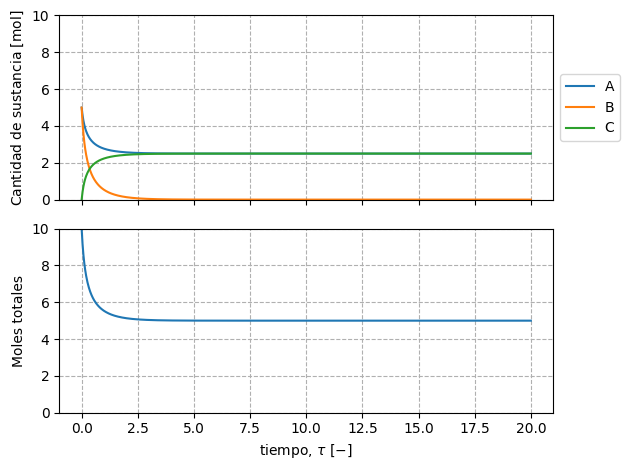

In [29]:
species = ["A", "B", "C"]
N0 = (5.0, 5.0, 0)
V = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solBatch = solve_ivp(
    fun=batch,
    t_span=t_span,
    y0=N0,
    args=(V,),
    events=batchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solBatch.y):
    ax0.plot(solBatch.t, y, label=specie)
ax1.plot(solBatch.t, np.sum(solBatch.y, axis=0))
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Moles totales")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

##### Mayor cantidad inicial de $\mathrm{A}$ que de $\mathrm{B}$

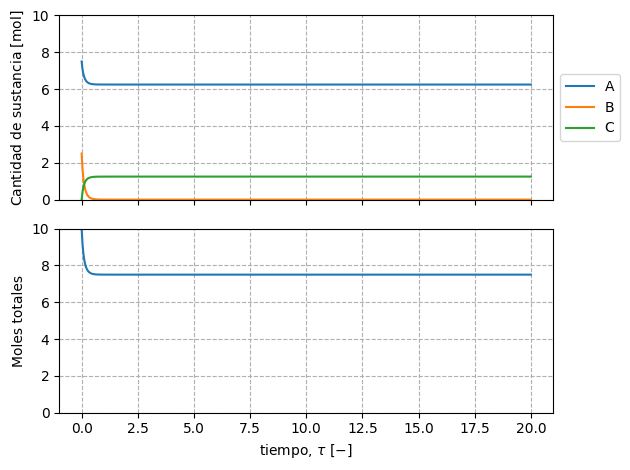

In [31]:
species = ["A", "B", "C"]
N0 = (7.5, 2.5, 0)
V = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solBatch = solve_ivp(
    batch,
    t_span,
    y0=N0,
    args=(V,),
    events=batchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solBatch.y):
    ax0.plot(solBatch.t, y, label=specie)
ax1.plot(solBatch.t, np.sum(solBatch.y, axis=0))
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Moles totales")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

##### Menor cantidad inicial de $\mathrm{A}$ que de $\mathrm{B}$

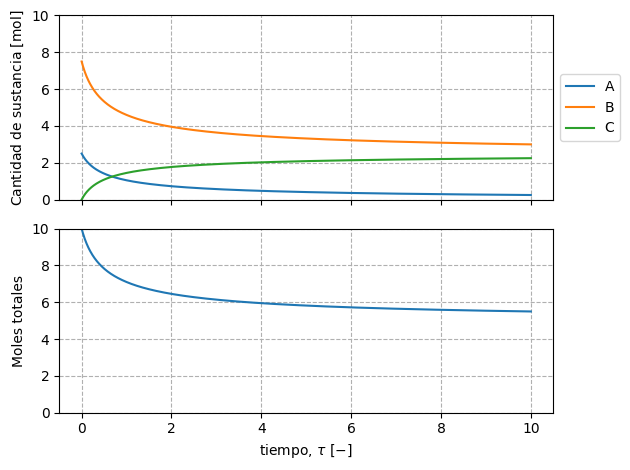

In [32]:
species = ["A", "B", "C"]
N0 = (2.5, 7.5, 0)
V = 1.0
t_span = (0, 10)
dt = 1e-2
t_eval = np.arange(t_span[0], t_span[1]+dt, dt)
solBatch = solve_ivp(
    batch,
    t_span,
    y0=N0,
    args=(V,),
    events=batchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solBatch.y):
    ax0.plot(solBatch.t, y, label=specie)
ax1.plot(solBatch.t, np.sum(solBatch.y, axis=0))
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Moles totales")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

#### 5.2.1.2 Reactor semi-batch

$$\frac{dN_{\mathrm{A}}}{dt} = r_{\mathrm{A}}V + F_{\mathrm{A}}^0$$
$$\frac{dN_{\mathrm{B}}}{dt} = r_{\mathrm{B}}V + F_{\mathrm{B}}^0$$
$$\frac{dN_{\mathrm{C}}}{dt} = r_{\mathrm{C}}V$$

In [33]:
def semiBatch(t, N, V, F0):
    C = N/V
    dN_dt = np.array([
        r_A(C[0], C[1])*V + F0[0],
        r_B(C[0], C[1])*V + F0[1],
        r_C(C[0], C[1])*V + F0[2]
    ])
    return dN_dt
def semiBatchEnd(t, N, V, F0):
    return np.min([N[0], N[1]])
semiBatchEnd.terminal = True
semiBatchEnd.direction = -1.0

##### Mismas cantidades iniciales, se agrega $\mathrm{A}$ poco a poco

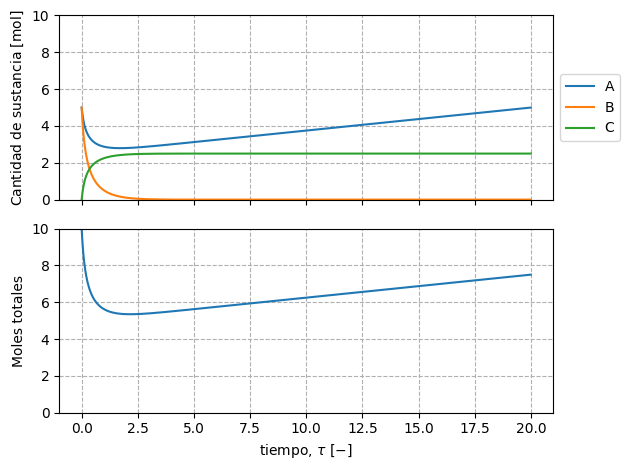

In [34]:
species = ["A", "B", "C"]
N0 = (5.0, 5.0, 0)
F0 = (0.125, 0.0, 0)
V = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solSemiBatch = solve_ivp(
    semiBatch,
    t_span,
    y0=N0,
    args=(V,F0),
    events=semiBatchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solSemiBatch.y):
    ax0.plot(solSemiBatch.t, y, label=specie)
ax1.plot(solSemiBatch.t, np.sum(solSemiBatch.y, axis=0))
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Moles totales")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

##### Mismas cantidades iniciales, se agrega $\mathrm{B}$ poco a poco

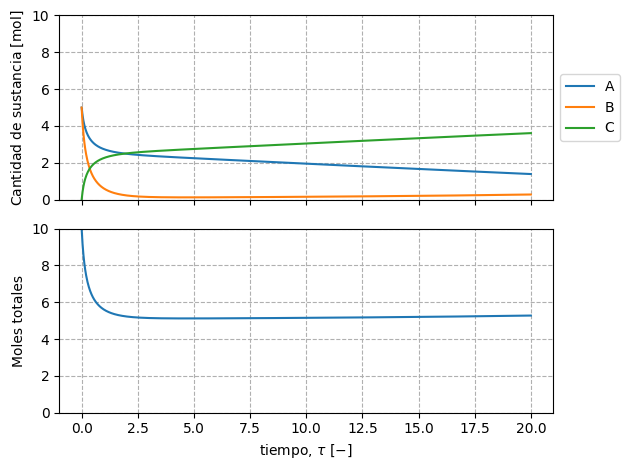

In [35]:
species = ["A", "B", "C"]
N0 = (5.0, 5.0, 0)
F0 = (0.0, 0.125, 0)
V = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solSemiBatch = solve_ivp(
    semiBatch,
    t_span,
    y0=N0,
    args=(V,F0),
    events=semiBatchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solSemiBatch.y):
    ax0.plot(solSemiBatch.t, y, label=specie)
ax1.plot(solSemiBatch.t, np.sum(solSemiBatch.y, axis=0))
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Moles totales")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

##### Mismas cantidades iniciales, se agregan $\mathrm{A}$ y $\mathrm{B}$ poco a poco

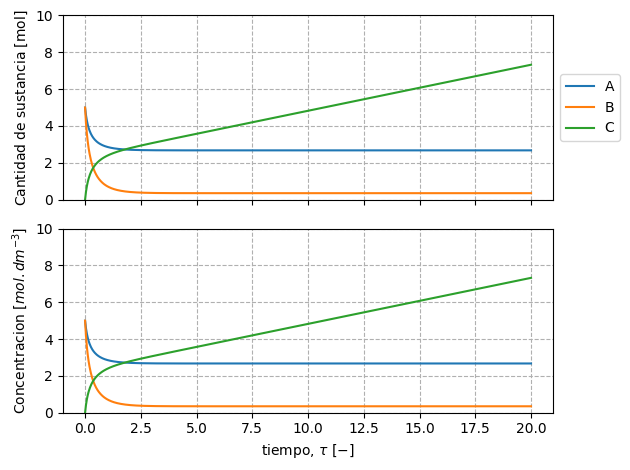

In [36]:
species = ["A", "B", "C"]
N0 = (5.0, 5.0, 0)
F0 = (0.25, 0.5, 0)
V = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solSemiBatch = solve_ivp(
    semiBatch,
    t_span,
    y0=N0,
    args=(V,F0),
    events=semiBatchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solSemiBatch.y):
    ax0.plot(solSemiBatch.t, y, label=specie)
    ax1.plot(solSemiBatch.t, y/V)
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Concentracion [$mol.dm^{-3}$]")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

### 5.2.2 Reactores con volumen variable (ejemplo)

In [37]:
def semiBatch(t, N, V0, Q, F0):
    V = V0 + Q*t
    C = N/V
    dN_dt = np.array([
        r_A(C[0], C[1])*V + F0[0],
        r_B(C[0], C[1])*V + F0[1],
        r_C(C[0], C[1])*V + F0[2]
    ])
    return dN_dt
def semiBatchEnd(t, N, V0, Q, F0):
    return np.min([N[0], N[1]])
semiBatchEnd.terminal = True
semiBatchEnd.direction = -1.0

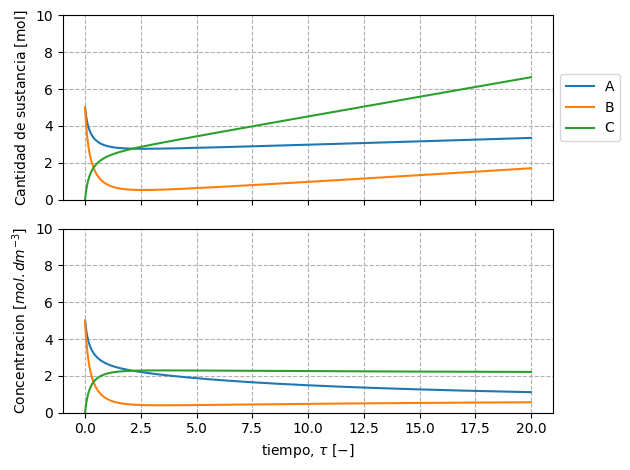

In [38]:
species = ["A", "B", "C"]
N0 = np.array((5.0, 5.0, 0))
F0 = np.array((0.25, 0.5, 0))
Q = 0.1
V0 = 1.0
t_span = (0, 20)
nt = 1000
t_eval = np.linspace(t_span[0], t_span[1], nt)
solSemiBatch = solve_ivp(
    semiBatch,
    t_span,
    y0=N0,
    args=(V0, Q, F0),
    events=semiBatchEnd,
    t_eval=t_eval
)

fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
for specie, y in zip(species, solSemiBatch.y):
    V = V0 + Q*solSemiBatch.t
    ax0.plot(solSemiBatch.t, y, label=specie)
    ax1.plot(solSemiBatch.t, y/V)
ax0.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])
ax0.set_ylabel(r"Cantidad de sustancia [$\mathrm{mol}$]")
ax1.set_ylabel(r"Concentracion [$mol.dm^{-3}$]")
ax1.set_xlabel(r"tiempo, $\tau$ [$\mathrm{-}$]")
ax0.set_ylim(0, 10)
ax1.set_ylim(0, 10)
ax0.grid(ls='--')
ax1.grid(ls='--')
fig.tight_layout()
plt.show()

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.

- ***[Levenspiel, 1998]***: Levenspiel, O. (1998) Chemical Reaction Engineering (3rd ed.). John Wiley & Sons Inc. URL: https://www.wiley.com/en-no/Chemical+Reaction+Engineering%2C+3rd+Edition-p-9780471254249